In [2]:
# 1. 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (6, 4)

In [ ]:
#2. 데이터 로드
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
#3. 데이터 구조 확인
print(df.shape)
print()
df.info()
print()
display(df.describe())

(20640, 10)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
#4. 결측치 확인
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
# 5. 중앙값 대치
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# 대치 후 확인
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

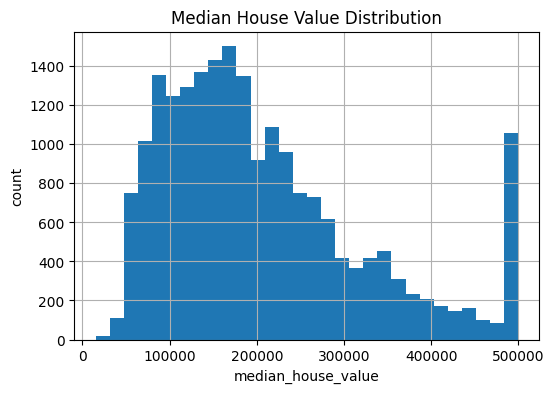

In [9]:
# 6. 타깃 변수 분포
df["median_house_value"].hist(bins=30)
plt.title("Median House Value Distribution")
plt.xlabel("median_house_value")
plt.ylabel("count")
plt.show()

- 집값 분포는 오른쪽으로 치우쳐 있으며, 고가 주택/ 가격 상한 구간에서 오차 해석에 주의가 필요하다.

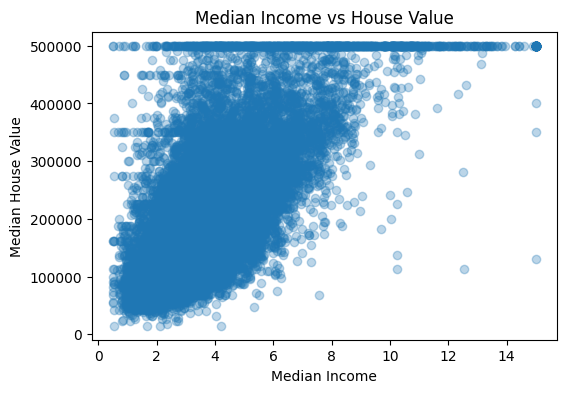

In [10]:
# 7. median_income vs median_house_value
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")
plt.show()

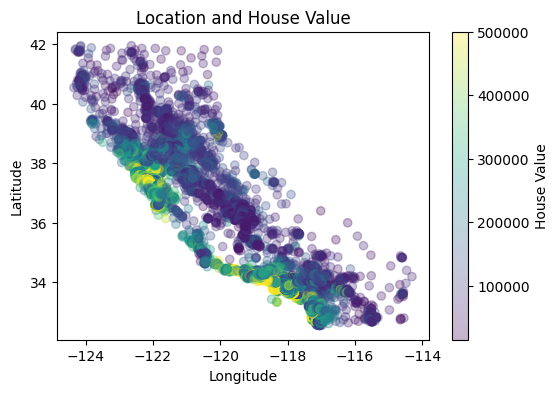

In [12]:
# 8. 위치 정보와 집값 관계
plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"], alpha=0.3)
plt.colorbar(label="House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location and House Value")
plt.show()

- 집값과 강한 관계를 보이는 변수는 median_income이고, 위치 정보인 longitude/latitude는 지역별 주택 가격 차이를 나타내는 공간적·비선형 관계를 가질 가능성이 있다.

In [13]:
# 9. 상관계수 확인
corr = df.corr(numeric_only=True)
corr["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

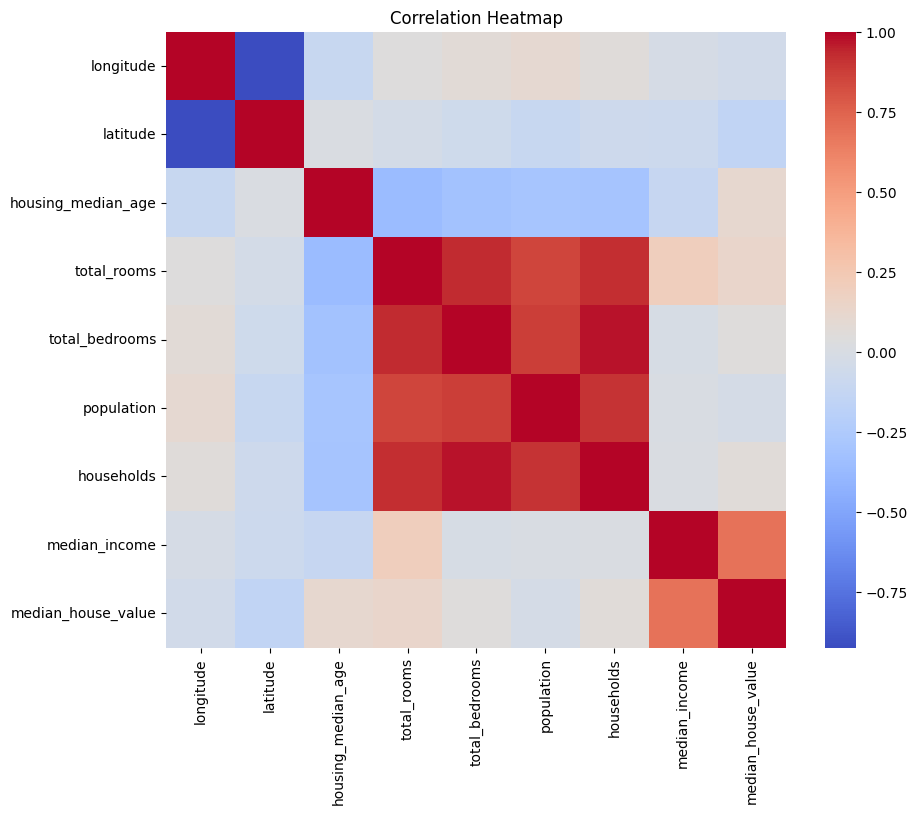

In [14]:
# 10. 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# 10.1. 범주형 변수 원-핫 인코딩
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
print("DataFrame shape after one-hot encoding:", df.shape)

# 11. x, y 분리
x = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

print("x shape:", x.shape)
print("y shape:", y.shape)

DataFrame shape after one-hot encoding: (20640, 14)
x shape: (20640, 13)
y shape: (20640,)


In [16]:
# 12. train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


x_train: (14448, 13)
x_test : (6192, 13)
y_train: (14448,)
y_test : (6192,)


In [17]:
# 13. 기준 모델 학습
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe_lr.fit(x_train, y_train)
y_pred_lr = pipe_lr.predict(x_test)

In [18]:
# 14. 기준 모델 평가
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R2  :", round(r2_lr, 4))


MAE : 50078.0988
RMSE: 68800.6488
R2  : 0.6394


In [21]:
# 15. Ridge 모델
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipe_ridge.fit(x_train, y_train)
y_pred_ridge = pipe_ridge.predict(x_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE :", round(mae_ridge, 4))
print("RMSE:", round(rmse_ridge, 4))
print("R2  :", round(r2_ridge, 4))

MAE : 50076.3063
RMSE: 68798.4864
R2  : 0.6394


- Ridge는 규제를 통해 과적합 완화 및 모델 안정성 향상 효과를 기대할 수 있다.
- Linear Regression 대비 RMSE는 거의 동일하지만 아주 조금 낮아졌다.
- Linear Regression: 68800.6488 → Ridge: 68798.4864

In [19]:
# 16. Random Forest 회귀 모델
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R2  :", round(r2_rf, 4))

MAE : 31720.7914
RMSE: 48657.2665
R2  : 0.8196


- Random Forest는 비선형적이고 복잡한 관계를 학습하는 데 유리하다.
- 가장 낮은 RMSE를 보인 모델은 Random Forest이다.

In [22]:
param_grid = {"model__alpha": [0.1, 1.0, 10.0, 50.0]}

grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_ridge.fit(x_train, y_train)
print("Best params:", grid_ridge.best_params_)
print("Best CV RMSE:", -grid_ridge.best_score_)

best_ridge = grid_ridge.best_estimator_
y_pred_best_ridge = best_ridge.predict(x_test)
mae_best_ridge = mean_absolute_error(y_test, y_pred_best_ridge)
rmse_best_ridge = np.sqrt(mean_squared_error(y_test, y_pred_best_ridge))
r2_best_ridge = r2_score(y_test, y_pred_best_ridge)
print("MAE :", round(mae_best_ridge, 4))
print("RMSE:", round(rmse_best_ridge, 4))
print("R2  :", round(r2_best_ridge, 4))

Best params: {'model__alpha': 10.0}
Best CV RMSE: 68990.24669225096
MAE : 50061.1109
RMSE: 68781.0355
R2  : 0.6396


In [23]:
# 17. 모델 비교 표
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Random Forest", "Ridge_tuned"],
    "MAE": [mae_lr, mae_ridge, mae_rf, mae_best_ridge],
    "RMSE": [rmse_lr, rmse_ridge, rmse_rf, rmse_best_ridge],
    "R2": [r2_lr, r2_ridge, r2_rf, r2_best_ridge],
})

results.sort_values("RMSE")


,Model,MAE,RMSE,R2
2,Random Forest,31720.791441,48657.266543,0.819622
3,Ridge_tuned,50061.110890,68781.035482,0.639567
1,Ridge,50076.306281,68798.486390,0.639384
0,Linear Regression,50078.098842,68800.648784,0.639361


RMSE 기준 가장 우수한 모델은 Random Forest이다. 이유는 RMSE가 48657.2665로 가장 낮고, R²도 0.8196으로 가장 높기 때문이다.

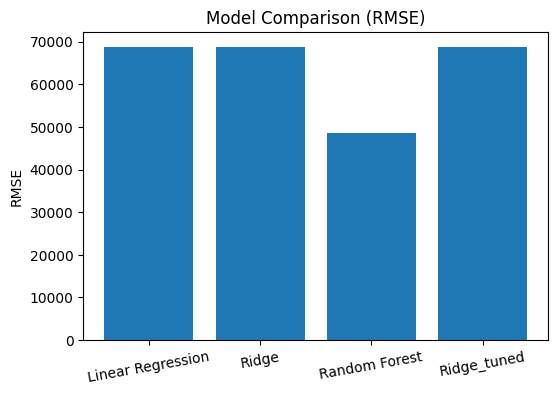

In [24]:
# 18. 모델별 RMSE 비교 시각화
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=10)
plt.show()


RMSE 기준 가장 우수한 모델은 Random Forest이다. 이유는 RMSE가 48657.2665로 가장 낮고, R²도 0.8196으로 가장 높기 때문이다.

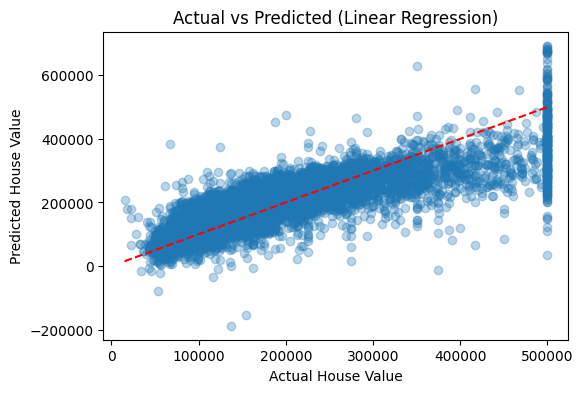

In [25]:
# 19. 실제값 vs 예측값 (Linear Regression)
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted (Linear Regression)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.show()

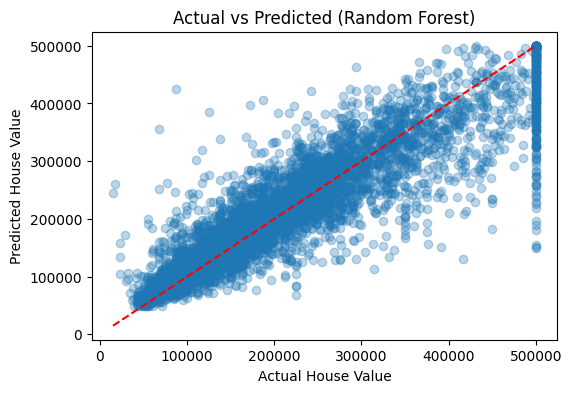

In [26]:
# 20. 실제값 vs 예측값 (Random Forest)
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted (Random Forest)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.show()

오차가 크게 나타난 구간은 고가 주택 구간, 특히 500,000 근처 가격 상한 구간이다. 이유는 데이터에 가격 상한이 존재하고, 고가 주택은 위치·소득·해안 접근성 등 여러 요인이 복잡하게 작용해 예측이 더 어렵기 때문이다.

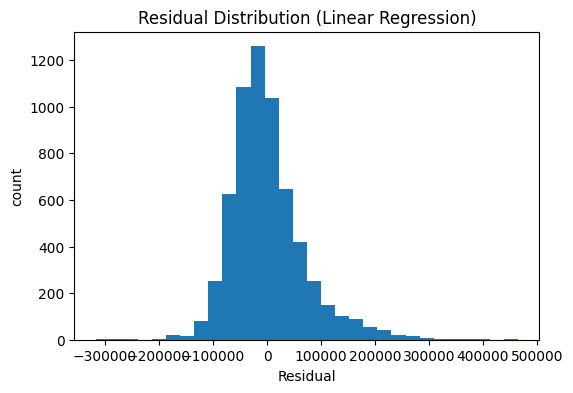

In [27]:
# 21. 잔차 분포 (Linear Regression)
residuals_lr = y_test - y_pred_lr

plt.hist(residuals_lr, bins=30)
plt.title("Residual Distribution (Linear Regression)")
plt.xlabel("Residual")
plt.ylabel("count")
plt.show()

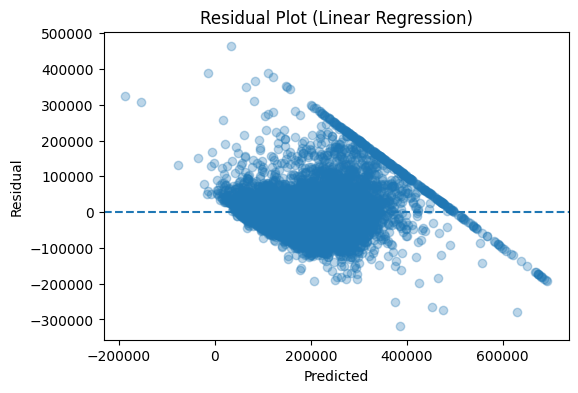

In [28]:
# 22. 잔차 산점도
plt.scatter(y_pred_lr, residuals_lr, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot (Linear Regression)")
plt.show()

median_income                 0.487945
ocean_proximity_INLAND        0.142947
longitude                     0.104064
latitude                      0.098338
housing_median_age            0.052568
population                    0.034489
total_rooms                   0.025109
total_bedrooms                0.024537
households                    0.018759
ocean_proximity_NEAR OCEAN    0.007007
ocean_proximity_<1H OCEAN     0.003168
ocean_proximity_NEAR BAY      0.000703
ocean_proximity_ISLAND        0.000364
dtype: float64

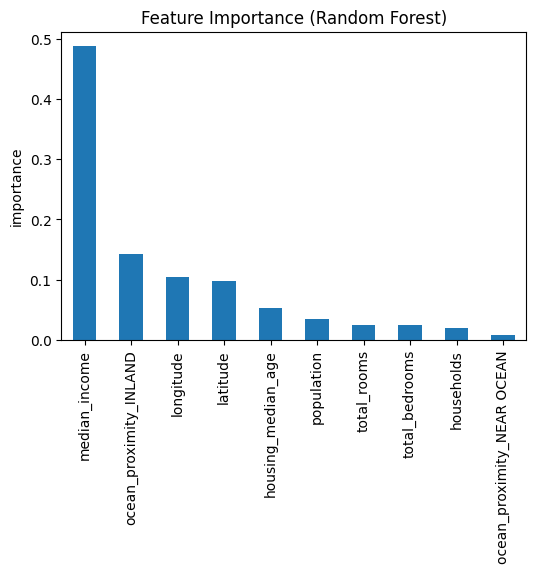

In [29]:
# 23. 변수 중요도
importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
display(importances)

importances.head(10).plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("importance")
plt.show()

In [30]:
# 24. Ridge alpha 비교
alphas = [0.1, 1.0, 10.0, 50, 100.0]
rows = []

for a in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=a))
    ])
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    
    rows.append({
        "alpha": a,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

- alpha 크기와 성능의 관계: alpha가 커질수록 RMSE가 소폭 감소하고 R²가 소폭 증가했지만, 개선 폭은 크지 않다.
- 규제가 모델의 계수/가중치 크기와 일반화 성능에 영향을 준다.

In [31]:
ridge_summary = pd.DataFrame(rows)
ridge_summary

,alpha,RMSE,R2
0,0.1,68800.430418,0.639363
1,1.0,68798.486390,0.639384
2,10.0,68781.035482,0.639567
3,50.0,68737.249651,0.640026
4,100.0,68730.830953,0.640093


- 본 프로젝트에서 가장 적합한 모델은 Random Forest Regressor이다.본 프로젝트에서 가장 적합한 모델은 Random Forest Regressor이다.
- 그 이유는 RMSE가 48657.2665로 가장 낮았기 때문이다.
- 주요 변수는 median_income와 ocean_proximity_INLAND로 나타났다.
- 다만 실제 적용 시에는 고가 주택 구간의 가격 상한(cap)과 과소예측 가능성에 주의가 필요하다.